In [230]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

# GETTING DATA 

In [231]:
def get_image_generator (preprocessing_function=None, validation_split=0.0, horizontal_flip=False):
    
    image_generator = ImageDataGenerator(preprocessing_function=preprocess_input,
                                         validation_split=validation_split,
                                         horizontal_flip=False)
    
    return image_generator

In [232]:
image_generator = get_image_generator(preprocessing_function=preprocess_input,
                                      validation_split=0.1,
                                      horizontal_flip=False)

In [233]:
def get_train_val_data_sets(directory, image_generator, target_size, batch_size=32): 

    train_set = image_generator.flow_from_directory(directory=directory, 
                                                    target_size=target_size,
                                                    batch_size=batch_size,
                                                    shuffle=True,
                                                    class_mode='categorical',
                                                    subset='training')

    validation_set = image_generator.flow_from_directory(directory=directory, 
                                                         target_size=target_size,
                                                         batch_size=batch_size,
                                                         shuffle=True,
                                                         class_mode='categorical',
                                                         subset='validation')
    return train_set, validation_set 

In [234]:
target_size = (160,160)
batch_size = 128

directory =  os.getcwd() + "\\105_classes_pins_dataset"

#classes = os.listdir(path= directory)


train_set, validation_set = get_train_val_data_sets(directory,
                                                    image_generator, 
                                                    target_size=target_size,
                                                    batch_size=batch_size)


Found 15831 images belonging to 105 classes.
Found 1703 images belonging to 105 classes.


# DATA VISUALIZATION 

In [239]:
def get_key(val, labels):
    for key, value in labels.items():
        if value == val:
            return key

def show_images(data_batch, labels, nrow, ncol, get_key):    

    batch_images = np.array(data_batch[0])
    batch_labels = np.array(data_batch[1] )
    

    plt.figure(figsize = (20,10))
    i=0
    for i in range(nrow*ncol):
        ax = plt.subplot(nrow, ncol, i+1)
        plt.imshow(batch_images[i])
        title = get_key(np.argmax(batch_labels[i]), labels)
        plt.title(title[5:].title())
        plt.axis('off')
     

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

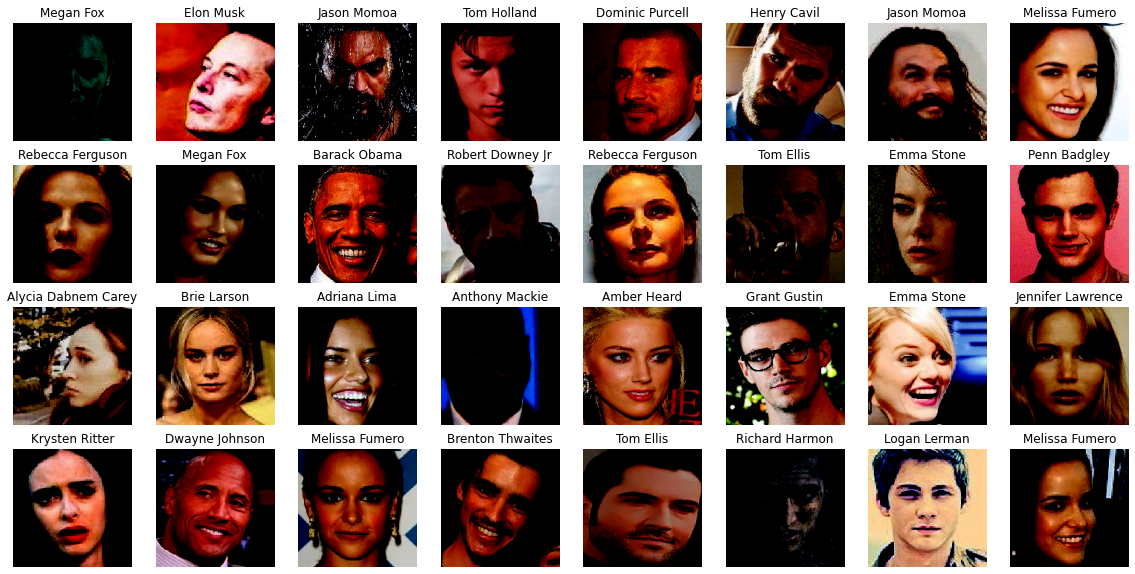

In [240]:
data_batch = next(train_set)

labels = (train_set.class_indices)

nrow = 4
ncol=8

show_images(data_batch, labels, nrow, ncol, get_key)